Importing Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils

import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
nz = 100
ngf = 64
ndf = 64
nc = 3

lr = 0.0002
beta1 = 0.5 

batch_size = 128
num_epochs = 20
image_size = 64

In [4]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

Data Loader

In [5]:
class CelebADataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.image_names = os.listdir(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_names[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image
        

In [6]:
dataset = CelebADataset(
    img_dir = "data/img_align_celeba",
    transform = transform
)


dataloader = DataLoader(
    dataset,
    batch_size = batch_size,
    shuffle =True,
    num_workers = 4,
    pin_memory = True
)

print("Dataset Size:", len(dataset))

Dataset Size: 202599


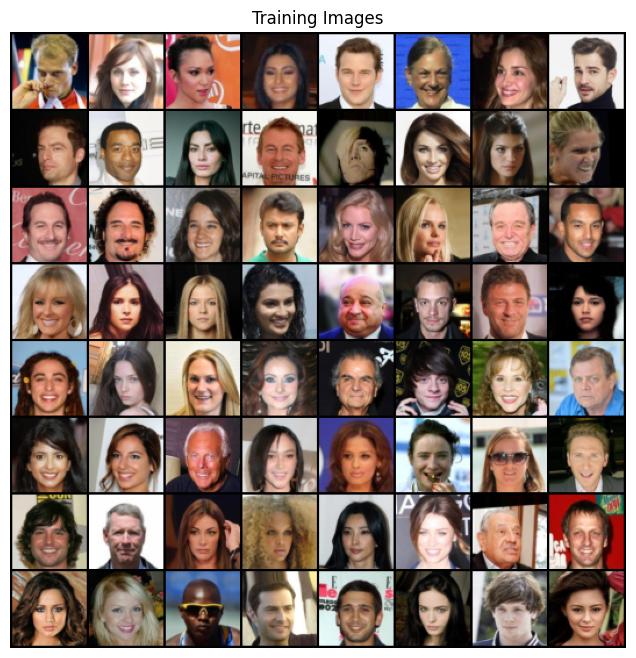

In [7]:
real_batch = next(iter(dataloader))

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")

plt.imshow(vutils.make_grid(real_batch[:64], padding=2, normalize=True).permute(1,2,0))
plt.show()

Generator

In [8]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(nz, ngf *8 ,4,1,0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4,2,1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4,2,1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4,2,1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4,2,1, bias=False),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

Discriminator

In [9]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            nn.Conv2d(nc, ndf, 4,2,1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4,2,1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4,2,1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, ndf*8, 4,2,1, bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*8, 1,4,1,0, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

In [10]:
netG = Generator().to(device)
netD = Discriminator().to(device)

print(netG)
print(netD)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [11]:
criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [12]:
fixed_noise = torch.randn(64, nz, 1, 1).to(device)

In [13]:
os.makedirs("training_images/model2", exist_ok=True)

Training

In [15]:
D_losses = []
G_losses = []

for epoch in range(num_epochs):
    for i, real_images in enumerate(dataloader):

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)
        

        netD.zero_grad()

        outputs_real = netD(real_images).view(-1,1)
        loss_real = criterion(outputs_real, real_labels)

        noise = torch.randn(batch_size, nz, 1,1, device=device)
        fake_images = netG(noise)

        outputs_fake = netD(fake_images.detach()).view(-1,1)
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D  = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()


        netG.zero_grad()

        outputs = netD(fake_images).view(-1,1)
        loss_G = criterion(outputs, real_labels)

        loss_G.backward()
        optimizerG.step()
    
    print(f"Epoch[{epoch+1}/{num_epochs}] | Loss D:{loss_D.item():.4f} | Loss G:{loss_G.item():.4f}")

    D_losses.append(loss_D.item())
    G_losses.append(loss_G.item())

    with torch.no_grad():
        fake = netG(fixed_noise).detach().cpu()
    
    vutils.save_image(fake, f"training_images/model2/epoch_{epoch+1}.png", normalize=True)


Epoch[1/20] | Loss D:0.4703 | Loss G:3.2391
Epoch[2/20] | Loss D:0.4446 | Loss G:3.6783
Epoch[3/20] | Loss D:0.2276 | Loss G:3.4292
Epoch[4/20] | Loss D:0.5406 | Loss G:2.6320
Epoch[5/20] | Loss D:0.5019 | Loss G:2.6625
Epoch[6/20] | Loss D:0.1322 | Loss G:3.8196
Epoch[7/20] | Loss D:0.1399 | Loss G:3.5239
Epoch[8/20] | Loss D:0.7296 | Loss G:3.2074
Epoch[9/20] | Loss D:0.3017 | Loss G:2.5888
Epoch[10/20] | Loss D:0.5540 | Loss G:4.2558
Epoch[11/20] | Loss D:0.4670 | Loss G:2.3844
Epoch[12/20] | Loss D:0.1507 | Loss G:4.2856
Epoch[13/20] | Loss D:0.0601 | Loss G:5.5601
Epoch[14/20] | Loss D:0.1503 | Loss G:3.6727
Epoch[15/20] | Loss D:0.0910 | Loss G:4.6842
Epoch[16/20] | Loss D:0.1746 | Loss G:4.1929
Epoch[17/20] | Loss D:2.0714 | Loss G:0.9912
Epoch[18/20] | Loss D:1.4363 | Loss G:13.8961
Epoch[19/20] | Loss D:0.0352 | Loss G:5.3088
Epoch[20/20] | Loss D:0.3487 | Loss G:3.0735


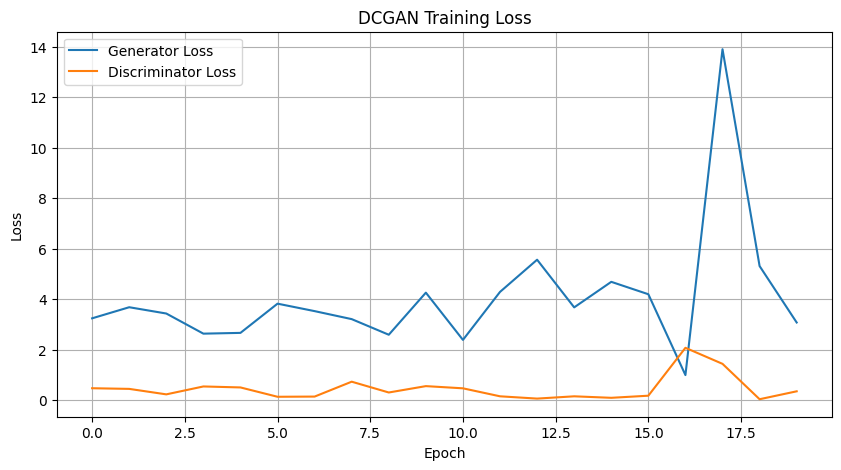

In [16]:
plt.figure(figsize=(10,5))
plt.title("DCGAN Training Loss")

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()